## Instalación y importación




In [1]:
!pip install transformers torch pyarrow mlflow -q

import pandas as pd
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import mlflow
import mlflow.sklearn
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score
)

print("MLflow version:", mlflow.__version__)
print("✅ Librerías listas")


/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


MLflow version: 3.9.0
✅ Librerías listas


## Carga de Datos de RAW

In [2]:
# ── Cargar datos ──────────────────────────────────────────
df_train = pd.read_parquet('sentiment_raw_train.parquet')
df_test  = pd.read_parquet('sentiment_raw_test.parquet')

print(f"Train shape : {df_train.shape}")
print(f"Test shape  : {df_test.shape}")
print("\nColumnas:", df_train.columns.tolist())

Train shape : (1360000, 2)
Test shape  : (240000, 2)

Columnas: ['text', 'label']


## Cargar el pipeline de HuggingFace

In [3]:
# ── Mapear etiquetas ──────────────────────────────────────
LABEL_MAP = {0: 'NEGATIVE', 1: 'POSITIVE', 4: 'POSITIVE'}
df_test['true_label'] = df_test['label'].map(LABEL_MAP)
df_test = df_test.dropna(subset=['true_label'])

# ── Pipeline HuggingFace ──────────────────────────────────
import torch, time
from tqdm.notebook import tqdm
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    revision="714eb0f",
    device=device
)

def run_inference(df, name, batch_size=4000):
    texts   = df['text'].astype(str).str[:512].tolist()
    total   = len(texts)
    preds, scores = [], []
    batches = [texts[i:i+batch_size] for i in range(0, total, batch_size)]

    print(f"\n🚀 {name} ({total:,} registros) | batch={batch_size}")
    start = time.time()

    with tqdm(total=total, desc=name, unit="tweet") as bar:
        for batch in batches:
            results = classifier(batch, truncation=True)
            for r in results:
                preds.append(r['label'])
                scores.append(r['score'])
            bar.update(len(batch))

    latency = time.time() - start
    df['pred_label'] = preds
    df['score']      = scores

    print(f"✅ {name} | {latency:.1f}s ({latency/60:.1f} min) | "
          f"{total/latency:,.0f} t/s | {latency/total*1000:.3f} ms/tweet")
    return df, latency

# ── Solo TEST (lo que pide el parcial) ───────────────────
df_test, lat_test = run_inference(df_test, "TEST")
df_test = df_test.dropna(subset=['true_label', 'pred_label'])

print(f"\nlat_test = {lat_test:.1f}s ({lat_test/60:.1f} min)")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


🚀 TEST (240,000 registros) | batch=4000


TEST:   0%|          | 0/240000 [00:00<?, ?tweet/s]

✅ TEST | 7620.2s (127.0 min) | 31 t/s | 31.751 ms/tweet

lat_test = 7620.2s (127.0 min)


## Métricas

In [4]:
def get_metricas(df):
    y_true   = df['true_label']
    y_pred   = df['pred_label']
    prob_pos = df.apply(
        lambda r: r['score'] if r['pred_label'] == 'POSITIVE' else 1 - r['score'], axis=1
    )
    return {
        'accuracy'  : accuracy_score(y_true, y_pred),
        'f1_macro'  : f1_score(y_true, y_pred, average='macro'),
        'precision' : precision_score(y_true, y_pred, average='macro'),
        'recall'    : recall_score(y_true, y_pred, average='macro'),
        'roc_auc'   : roc_auc_score((y_true == 'POSITIVE').astype(int), prob_pos)
    }

metrics_test = get_metricas(df_test)

print(f"\n{'='*55}")
print(f"📊 RESULTADOS DistilBERT — TEST")
print(f"{'='*55}")
print(f"  Accuracy  : {metrics_test['accuracy']:.4f}")
print(f"  F1 Macro  : {metrics_test['f1_macro']:.4f}")
print(f"  Precision : {metrics_test['precision']:.4f}")
print(f"  Recall    : {metrics_test['recall']:.4f}")
print(f"  ROC-AUC   : {metrics_test['roc_auc']:.4f}")
print()
print(classification_report(df_test['true_label'], df_test['pred_label'],
                            target_names=['NEGATIVE', 'POSITIVE']))



📊 RESULTADOS DistilBERT — TEST
  Accuracy  : 0.7109
  F1 Macro  : 0.7081
  Precision : 0.7190
  Recall    : 0.7108
  ROC-AUC   : 0.7934

              precision    recall  f1-score   support

    NEGATIVE       0.68      0.81      0.74    120129
    POSITIVE       0.76      0.61      0.68    119871

    accuracy                           0.71    240000
   macro avg       0.72      0.71      0.71    240000
weighted avg       0.72      0.71      0.71    240000



## Gráficas

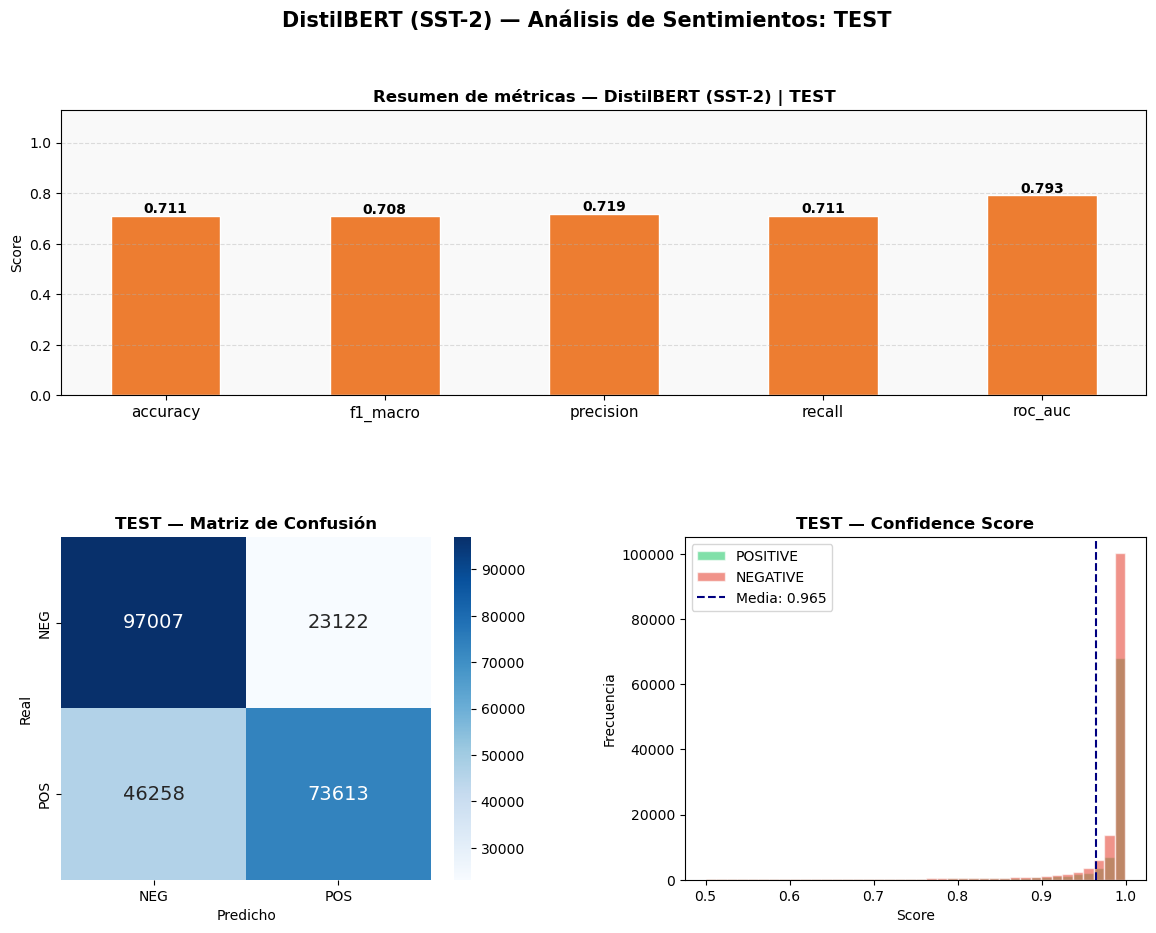

✅ Guardado: 05_distilbert_dashboard.png


In [5]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle('DistilBERT (SST-2) — Análisis de Sentimientos: TEST',
             fontsize=15, fontweight='bold')

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35,
                       height_ratios=[1, 1.2])

# ── FILA 0: Barras de métricas (span completo) ────────────
ax_m = fig.add_subplot(gs[0, :])

metric_labels = ['accuracy', 'f1_macro', 'precision', 'recall', 'roc_auc']
vals_test     = [metrics_test[k] for k in metric_labels]

x = np.arange(len(metric_labels))
bars = ax_m.bar(x, vals_test, 0.5, color='#ED7D31', edgecolor='white')
ax_m.set_xticks(x)
ax_m.set_xticklabels(metric_labels, fontsize=11)
ax_m.set_ylim(0, 1.13)
ax_m.set_ylabel('Score')
ax_m.set_title('Resumen de métricas — DistilBERT (SST-2) | TEST',
               fontsize=12, fontweight='bold')
ax_m.grid(axis='y', linestyle='--', alpha=0.4)
ax_m.set_facecolor('#F9F9F9')
for bar, val in zip(bars, vals_test):
    ax_m.text(bar.get_x() + bar.get_width()/2, val + 0.01,
              f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# ── FILA 1: Confusión + Confidence Score ──────────────────
y_true = df_test['true_label'].tolist()
y_pred = df_test['pred_label'].tolist()

ax_cm = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_true, y_pred, labels=['NEGATIVE', 'POSITIVE'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
            xticklabels=['NEG', 'POS'], yticklabels=['NEG', 'POS'],
            annot_kws={"size": 14})
ax_cm.set_title('TEST — Matriz de Confusión', fontweight='bold')
ax_cm.set_ylabel('Real'); ax_cm.set_xlabel('Predicho')

ax_sc = fig.add_subplot(gs[1, 1])
for lbl, color in zip(['POSITIVE', 'NEGATIVE'], ['#2ecc71', '#e74c3c']):
    subset = df_test[df_test['pred_label'] == lbl]['score']
    ax_sc.hist(subset, bins=40, alpha=0.6, label=lbl, color=color, edgecolor='white')
ax_sc.axvline(df_test['score'].mean(), color='navy', linestyle='--',
              label=f"Media: {df_test['score'].mean():.3f}")
ax_sc.set_title('TEST — Confidence Score', fontweight='bold')
ax_sc.set_xlabel('Score'); ax_sc.set_ylabel('Frecuencia')
ax_sc.legend()

plt.savefig('05_distilbert_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado: 05_distilbert_dashboard.png")


## Registro en MLflow

In [6]:
df_test[['text','true_label','pred_label','score']].to_csv(
    'distilbert_test_predictions.csv', index=False
)

mlflow.set_tracking_uri("http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
mlflow.set_experiment("Parcial_1_NLP")

with mlflow.start_run(run_name="HuggingFace_DistilBERT_SST2_Reference") as run:

    mlflow.set_tags({
        "user"           : "alan osorio",
        "model_type"     : "DistilBERT",
        "architecture"   : "Transformer",
        "encoding"       : "Tokenizer (WordPiece)",
        "dataset"        : "Sentiment140Twitter",
        "notebook"       : "05_distilbert.ipynb",
        "experiment_type": "D_comparison_huggingface",
        "note"           : "SST-2 model NOT trained on Twitter — reference baseline only"
    })

    mlflow.log_params({
        "model_name"   : "distilbert-base-uncased-finetuned-sst-2-english",
        "batch_size"   : 16,
        "truncation"   : True,
        "max_length"   : 512,
        "device"       : "GPU" if device == 0 else "CPU",
        "pretrained_on": "SST-2 (movie reviews)",
        "n_test"       : len(df_test),
    })

    mlflow.log_metrics({
        "test_accuracy"        : round(metrics_test['accuracy'],  4),
        "test_f1_macro"        : round(metrics_test['f1_macro'],  4),
        "test_precision"       : round(metrics_test['precision'], 4),
        "test_recall"          : round(metrics_test['recall'],    4),
        "test_roc_auc"         : round(metrics_test['roc_auc'],   4),
        "latency_test_sec"     : round(lat_test, 2),
        "latency_ms_per_sample": round(lat_test / len(df_test) * 1000, 4),
    })

    mlflow.log_artifact("05_distilbert_dashboard.png")
    mlflow.log_artifact("distilbert_test_predictions.csv")

    print("=" * 55)
    print("  ✅ Run registrado exitosamente en MLflow")
    print(f"  Servidor     : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
    print(f"  Experimento  : Parcial_1_NLP")
    print(f"  Run ID       : {run.info.run_id}")
    print(f"  Test F1      : {metrics_test['f1_macro']:.4f}")
    print(f"  Test AUC     : {metrics_test['roc_auc']:.4f}")
    print(f"  Latencia Test: {lat_test:.2f}s")
    print("=" * 55)


2026/03/08 02:13:49 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/08 02:13:49 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/08 02:13:49 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/08 02:13:49 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/08 02:13:49 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/08 02:13:49 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/08 02:13:49 WARNING mlflow.tracking.request_header.regis

  ✅ Run registrado exitosamente en MLflow
  Servidor     : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000
  Experimento  : Parcial_1_NLP
  Run ID       : 72cfa8f967b9471ba60252001f2671c3
  Test F1      : 0.7081
  Test AUC     : 0.7934
  Latencia Test: 7620.25s
🏃 View run HuggingFace_DistilBERT_SST2_Reference at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1/runs/72cfa8f967b9471ba60252001f2671c3
🧪 View experiment at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1
